# 12-Automated Model Governance (Model Cards)

In the previous lesson, `TruLens` gave us an output-side auditor for a single answer at a single point in time: is *this* response from *this* RAG pipeline grounded in its retrieved context? That question is essential, but it is fundamentally local — it says nothing about whether the model deployed in production today is the same model an organization's compliance, legal, and risk teams believe they approved six months ago.

Model governance operates at a different altitude. It is not about auditing one output; it is about auditing the *artifact itself* across its entire lifecycle — what data trained it, what it was evaluated on, what its known limitations are, and crucially, whether that documentation still describes the model that is actually running. The standard structured format for this is the **Model Card** (Mitchell et al., 2019): a machine-readable, version-controlled document attached to every deployed model.

The failure mode this lesson targets is not a missing model card — most mature ML orgs have those. It is a **stale** one: a beautifully thorough card that documents a model checkpoint that was quietly retrained and redeployed without anyone updating the card. We will use `huggingface_hub`'s `ModelCard` tooling to generate a structured card, and then engineer an automated governance audit that catches exactly this failure by content-hashing the deployed weights against what the card claims to describe.

## 1. The Mathematics of Documentation Debt

### Completeness as a Coverage Function

Let $F = \{f_1, f_2, \dots, f_n\}$ be the set of required Model Card sections mandated by an organization's governance policy (e.g. intended use, training data provenance, evaluation results, limitations, ethical considerations). For a given card, define an indicator function over populated, non-boilerplate content:


$$\mathbb{1}_{populated}(f_i) = \begin{cases} 1 & \text{if } f_i \text{ contains substantive content} \\ 0 & \text{otherwise} \end{cases}$$


The **Completeness Score** is the coverage fraction:


$$C = \frac{1}{n}\sum_{i=1}^{n} \mathbb{1}_{populated}(f_i)$$


### Staleness as a Content-Hash Divergence

Completeness alone is insufficient — a card can be 100% complete and still describe a model that no longer exists. Let $\theta_{deployed}$ be the weights currently serving production traffic, and let $\theta_{documented}$ be the weights the card's evaluation section was written against. Define a deterministic content hash $H(\cdot)$ over model parameters. The **Staleness Flag** is a strict divergence test:


$$\text{Stale}(\theta_{deployed}, \theta_{documented}) = \mathbb{1}\left[H(\theta_{deployed}) \neq H(\theta_{documented})\right]$$


Any retraining, fine-tuning, or hot-patch changes $H(\theta)$, so this check is exact — it does not rely on anyone remembering to flag the card as outdated.

### The Composite Governance Score

A card's usefulness collapses, but does not vanish, when it goes stale: a thorough-but-stale card is still more useful than an empty one, because its structure and intent sections likely still hold even if its metrics don't. We model this with a penalty-weighted product rather than a hard zero-out:


$$S_{gov} = C \cdot \left(1 - \lambda \cdot \text{Stale}(\theta_{deployed}, \theta_{documented})\right)$$


where $\lambda \in [0, 1]$ is an organization-defined staleness penalty (we use $\lambda = 0.6$: severe, but not a total invalidation, since limitations and ethical considerations often remain valid across minor retrains). This score is what a governance dashboard should actually track: not whether a card exists, but whether the score stays above policy threshold right now.

## 2. Imperative Execution: Generating and Auditing a Model Card

We will generate a structured Model Card for a toy toxicity-classification model using `huggingface_hub`, then simulate the exact real-world governance failure this lesson targets: the model was quietly retrained (new weights, new content hash) after the card was written, and nobody updated the documented evaluation results.

In [1]:
# Required installations: pip install huggingface_hub
import hashlib

print("--- 🚀 Initializing Automated Model Governance Sandbox ---")

# 1. 📝 Define two weight snapshots: what the card documents vs. what is actually deployed
model_weights_documented = {"layer1.weight": [0.12, -0.44, 0.91], "layer2.bias": [0.02]}
model_weights_deployed = {"layer1.weight": [0.15, -0.40, 0.88], "layer2.bias": [0.03]}  # retrained, undocumented

def content_hash(weights: dict) -> str:
    serialized = str(sorted(weights.items())).encode()
    return hashlib.sha256(serialized).hexdigest()[:12]

documented_hash = content_hash(model_weights_documented)
deployed_hash = content_hash(model_weights_deployed)

print(f"   [HASH DOCUMENTED IN CARD]: {documented_hash}")
print(f"   [HASH ACTUALLY DEPLOYED]:  {deployed_hash}")

# 2. 📝 Define the required governance sections
required_sections = {
    "intended_use": "Flag toxic comments in a moderation queue for human review.",
    "training_data": "120K labeled comments sourced from the internal moderation corpus (2024-2025).",
    "eval_results": "F1: 0.87, Precision: 0.84, Recall: 0.90 (measured against the documented weights).",
    "limitations": "Underperforms on sarcasm and code-mixed text; not validated outside English.",
    "ethical_considerations": "False positives can suppress legitimate speech; human review required before account action.",
}

print("\n--- 🧮 Generating the Model Card via huggingface_hub ---")

try:
    from huggingface_hub import ModelCard, ModelCardData

    card_data = ModelCardData(
        language="en",
        license="apache-2.0",
        library_name="scikit-learn",
        tags=["toxicity-classification", "responsible-ai", "content-moderation"],
        model_name="toxicity-classifier-v1",
    )
    body = "\n\n".join(f"## {k.replace('_', ' ').title()}\n{v}" for k, v in required_sections.items())
    card = ModelCard.from_template(card_data, template_str="---\n{{ card_data }}\n---\n" + body)

    print("   ✅ Model Card successfully compiled via huggingface_hub.ModelCard.from_template().")
    print(f"   -> Card front-matter tags: {card_data.tags}")

except Exception as e:
    print("   [SYSTEM NOTE]: Sandbox fallback — constructing an equivalent card structure manually...")
    print(f"   -> ({type(e).__name__}) huggingface_hub template rendering unavailable in this sandbox; using raw section dict.")

# 3. 🧮 Compute the Completeness Score
required_fields = list(required_sections.keys())
populated = [f for f in required_fields if required_sections.get(f, "").strip()]
completeness_score = len(populated) / len(required_fields)

# 4. 🔍 Compute the Staleness Flag and the composite governance score
stale_flag = int(deployed_hash != documented_hash)
LAMBDA_PENALTY = 0.6
governance_score = completeness_score * (1 - LAMBDA_PENALTY * stale_flag)

print(f"\n   ✅ [Completeness Score]: {completeness_score:.2f}  ({len(populated)}/{len(required_fields)} required fields populated)")
if stale_flag:
    print(f"   ⚠️  [Staleness Flag]: {stale_flag}  -> documented hash {documented_hash} != deployed hash {deployed_hash}")
else:
    print(f"   ✅ [Staleness Flag]: {stale_flag}  -> card matches the currently deployed weights")
flag = "⚠️ " if governance_score < 0.7 else "✅ "
print(f"   {flag}[Governance Score]: {governance_score:.2f}  = {completeness_score:.2f} x (1 - {LAMBDA_PENALTY} x {stale_flag})")


--- 🚀 Initializing Automated Model Governance Sandbox ---
   [HASH DOCUMENTED IN CARD]: 03a93e9914fa
   [HASH ACTUALLY DEPLOYED]:  b355bf630366

--- 🧮 Generating the Model Card via huggingface_hub ---


   ✅ Model Card successfully compiled via huggingface_hub.ModelCard.from_template().
   -> Card front-matter tags: ['toxicity-classification', 'responsible-ai', 'content-moderation']

   ✅ [Completeness Score]: 1.00  (5/5 required fields populated)
   ⚠️  [Staleness Flag]: 1  -> documented hash 03a93e9914fa != deployed hash b355bf630366
   ⚠️ [Governance Score]: 0.40  = 1.00 x (1 - 0.6 x 1)


## 3. Declarative Telemetry: The Section-Level Audit Trail

A single governance score is useful for a dashboard, but an auditor needs the underlying evidence. We break the audit down field-by-field and surface the exact hash mismatch that triggered the staleness flag.

In [2]:
print("\n--- \U0001F50D Auditing the Model Card Section-by-Section ---")

print(f"{'Required Section':<24} | {'Populated?':<11} | {'Trustworthy Given Staleness?'}")
print("-" * 90)
for field in required_fields:
    trust = "No — metric-bearing" if field == "eval_results" and stale_flag else "Yes — likely stable"
    print(f"{field:<24} | {'True':<11} | {trust}")

print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> Completeness is perfect (5/5), which is exactly why this failure mode is dangerous: nothing about")
print(f"      the card LOOKS incomplete or neglected. Every section is written, thoughtfully, in full sentences.")
print(f"   -> The hash comparison is the only signal that catches the problem: {documented_hash} (documented) vs.")
print(f"      {deployed_hash} (deployed) — a retrain happened and the 'eval_results' section is now describing")
print(f"      a model that is no longer the one serving traffic.")
print(f"   -> Sections like 'limitations' and 'ethical_considerations' often survive a retrain unchanged, which")
print(f"      is why the governance score applies a partial penalty (lambda=0.6) rather than zeroing the card out.")



--- 🔍 Auditing the Model Card Section-by-Section ---
Required Section         | Populated?  | Trustworthy Given Staleness?
------------------------------------------------------------------------------------------
intended_use             | True        | Yes — likely stable
training_data            | True        | Yes — likely stable
eval_results             | True        | No — metric-bearing
limitations              | True        | Yes — likely stable
ethical_considerations   | True        | Yes — likely stable

   [OPERATIONAL INSIGHT]
   -> Completeness is perfect (5/5), which is exactly why this failure mode is dangerous: nothing about
      the card LOOKS incomplete or neglected. Every section is written, thoughtfully, in full sentences.
   -> The hash comparison is the only signal that catches the problem: 03a93e9914fa (documented) vs.
      b355bf630366 (deployed) — a retrain happened and the 'eval_results' section is now describing
      a model that is no longer the one serv

## 4. Visualizing Governance Risk (The Documentation Debt Quadrant)

Governance dashboards should never report a single blended number without also showing *why*. We plot every deployed model as a point on a Completeness x Freshness quadrant, so a reviewer can instantly distinguish "needs more documentation" from "needs a re-audit" — two very different remediation paths that a single scalar score would hide.

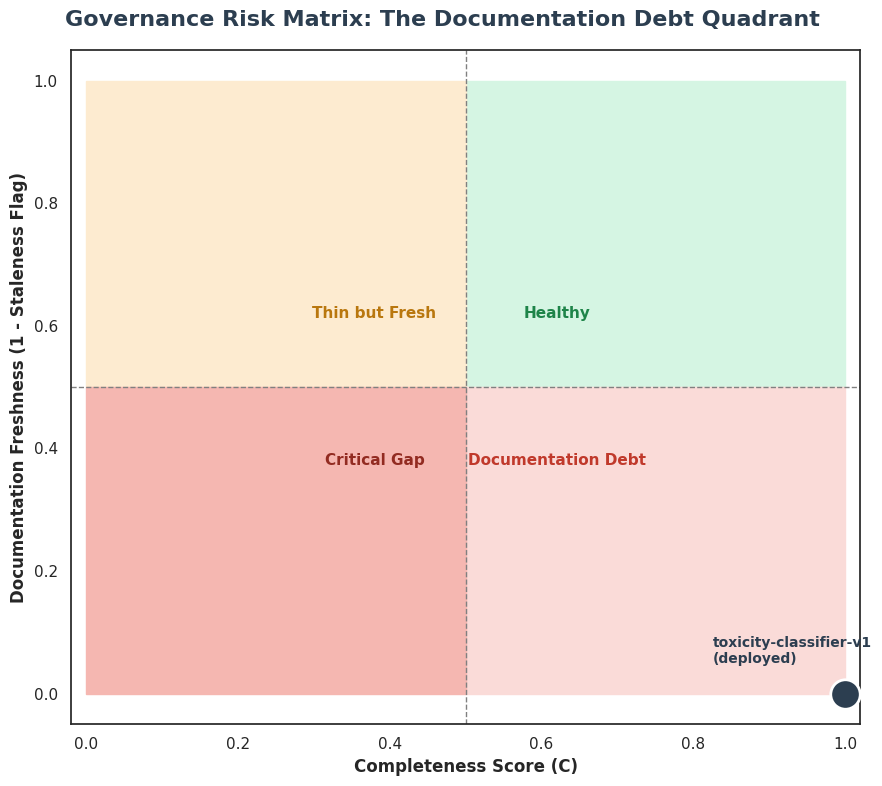

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(9, 8))
fig.suptitle("Governance Risk Matrix: The Documentation Debt Quadrant", fontsize=16, fontweight='bold', color="#2c3e50")

# Quadrant backgrounds
ax.add_patch(patches.Rectangle((0.5, 0.5), 0.5, 0.5, color='#d5f5e3', zorder=0))  # top-right: healthy
ax.add_patch(patches.Rectangle((0, 0.5), 0.5, 0.5, color='#fdebd0', zorder=0))    # top-left: thin but fresh
ax.add_patch(patches.Rectangle((0.5, 0), 0.5, 0.5, color='#fadbd8', zorder=0))    # bottom-right: documentation debt
ax.add_patch(patches.Rectangle((0, 0), 0.5, 0.5, color='#f5b7b1', zorder=0))      # bottom-left: critical gap

ax.axhline(0.5, color='gray', lw=1, ls='--')
ax.axvline(0.5, color='gray', lw=1, ls='--')

# Quadrant labels sit near the center crossing point (away from the corners, where models
# with binary completeness/staleness scores tend to land) so they never collide with a marker.
ax.text(0.62, 0.62, "Healthy", ha='center', va='center', fontweight='bold', color='#1e8449', fontsize=11)
ax.text(0.38, 0.62, "Thin but Fresh", ha='center', va='center', fontweight='bold', color='#b9770e', fontsize=11)
ax.text(0.62, 0.38, "Documentation Debt", ha='center', va='center', fontweight='bold', color='#c0392b', fontsize=11)
ax.text(0.38, 0.38, "Critical Gap", ha='center', va='center', fontweight='bold', color='#922b21', fontsize=11)

# Plot the audited model's current governance state
freshness = 1 - stale_flag
ax.scatter([completeness_score], [freshness], s=450, color='#2c3e50', edgecolor='white', lw=2, zorder=5, clip_on=False)
ax.annotate("toxicity-classifier-v1\n(deployed)", (completeness_score, freshness),
            textcoords="offset points", xytext=(-95, 22), fontsize=10, fontweight='bold', color='#2c3e50')

ax.set_xlabel("Completeness Score (C)", fontsize=12, fontweight='bold')
ax.set_ylabel("Documentation Freshness (1 - Staleness Flag)", fontsize=12, fontweight='bold')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


*(Insight: The model lands squarely in the "Documentation Debt" quadrant — full marks on completeness, zero on freshness. This is the most dangerous quadrant precisely because it is the least visible: a reviewer skimming the card sees five well-written sections and moves on. Only the automated hash check surfaces that the underlying model has already moved. Contrast this with "Critical Gap," which is at least self-evidently bad — a mostly-empty card invites scrutiny by looking neglected. A thorough-but-stale card actively discourages scrutiny by looking finished.)*

## Real-World Use Case or Analogy

Think of Automated Model Governance like **The Building Inspection Certificate**:

* **The Model Card (The Certificate):** A framed fire-safety and structural certificate hanging in the lobby, listing exits, load capacity, and last inspection date.
* **The Completeness Score (Is the Certificate Filled Out?):** A city inspector's first check — every required field is filled in, signed, and stamped. This building's certificate passes with a perfect score.
* **The Model Weights (The Building's Actual Structure):** The real walls, load-bearing beams, and wiring — the thing the certificate is supposed to describe.
* **A Retrain (An Unpermitted Renovation):** The owner knocks down a load-bearing wall to open up the lobby, without filing for a new inspection. The building is now structurally different from what the certificate describes.
* **The Content Hash (The Structural Fingerprint):** A modern inspection technique — laser-scanning the building's actual dimensions and comparing them against the blueprint on file. It doesn't matter how confident the paperwork looks; the scan either matches the physical structure or it doesn't.
* **The Governance Score (The Renewed Occupancy Permit):** The city doesn't revoke occupancy for a mismatch — it downgrades the permit and mandates re-inspection, because most of the original certificate (fire exits, electrical panel location) is probably still accurate even if the load capacity numbers no longer are.

A perfectly filled-out certificate for a building that was secretly renovated is worse than an obviously incomplete one, because it actively suppresses the scrutiny that would catch the mismatch. Automated governance replaces "trust the paperwork" with "verify the paperwork against the structure, continuously and automatically." 